In [1]:
import numpy as np
import pandas as pd
import logging
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

In [ ]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("sqlite://../mlflow.db")
mlflow.set_experiment("sales_forecasting")

c:\Users\devan\Desktop\5_DataScience_Project\sales_forecasting\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/06/13 10:59:30 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/13 10:59:30 INFO mlflow.store.db.utils: Updating database tables
2026/06/13 10:59:31 INFO mlflow.tracking.fluent: Experiment with name 'sales_forecasting' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///c:/Users/devan/Desktop/5_DataScience_Project/sales_forecasting/notebooks/mlruns/1', creation_time=1781328571396, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781328571396, lifecycle_stage='active', name='sales_forecasting', tags={}, trace_location=None, workspace='default'>

In [3]:
import os
import sys

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.logger import setup_logging
setup_logging(log_dir='../logs')

logger = logging.getLogger('modeling')
logger.info('Modeling notebook started')

2026-06-13 10:59:31 | INFO     | src.logger | Logging to file: ../logs\run_20260613_105931.log
2026-06-13 10:59:31 | INFO     | modeling | Modeling notebook started


In [4]:
train_data_path = r"..\data\processed\train.csv"
pd.set_option('display.max_columns', None)
df = pd.read_csv(train_data_path)
df.head()

,StateHoliday,PromoInterval,StoreType,Assortment,DayOfWeek,Open,Promo,SchoolHoliday,CompetitionDistance,Promo2,Promo2SinceDays,CompetitionOpenSinceDays,Year,Month,Sales
0,0.0,3.0,2.0,0.0,5,1,1,1,1270.0,0,0.0,2524.0,2015,7,5263
1,0.0,1.0,0.0,0.0,5,1,1,1,570.0,1,1950.0,2829.0,2015,7,6064
2,0.0,1.0,0.0,0.0,5,1,1,1,14130.0,1,1579.0,3164.0,2015,7,8314
3,0.0,3.0,2.0,2.0,5,1,1,1,620.0,0,0.0,2159.0,2015,7,13995
4,0.0,3.0,0.0,0.0,5,1,1,1,29910.0,0,0.0,121.0,2015,7,4822


In [5]:
X = df.drop(columns='Sales')
y = df['Sales']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
param_grid = {
    'max_depth': [35, 40, 45],
    'min_samples_split': [8, 10, 12],
    'min_samples_leaf': [2, 3, 4]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error'
)

In [9]:
with mlflow.start_run(run_name="DecisionTree_GridSearch"):
    grid.fit(X_train, y_train)
    y_pred = grid.predict(X_test)
    train_pred = grid.predict(X_train)

    best_parameter = grid.best_params_
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2_test = r2_score(y_test, y_pred)
    r2_train = r2_score(y_train, train_pred)

    mlflow.log_params(best_parameter)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2_test", r2_test)
    mlflow.log_metric("r2_train", r2_train)

    mlflow.sklearn.log_model(grid.best_estimator_, "decision_tree_model")

    print(f"Best params: {best_parameter}")
    print(f"RMSE: {rmse:.4f} | R2 Test: {r2_test:.4f} | R2 Train: {r2_train:.4f}")

2026/06/13 11:02:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 11:02:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best params: {'max_depth': 40, 'min_samples_leaf': 4, 'min_samples_split': 12}
RMSE: 1081.8571 | R2 Test: 0.9209 | R2 Train: 0.9600


In [10]:
best_model = grid.best_estimator_
importance = best_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})
feature_importance

,Feature,Importance
0,StateHoliday,0.000699
1,PromoInterval,0.017926
2,StoreType,0.028324
3,Assortment,0.017055
4,DayOfWeek,0.038296
5,Open,0.478887
6,Promo,0.076628
7,SchoolHoliday,0.003591
8,CompetitionDistance,0.223765
9,Promo2,0.003327


In [11]:
print("MSE  :", mse)
print("MAE :", mae)
print("RMSE :", rmse)
print("R2 Test :", r2_test)
print("R2 Train:", r2_train)

MSE  : 1170414.879404331
MAE : 636.9276607573022
RMSE : 1081.857143713684
R2 Test : 0.9209246004047901
R2 Train: 0.9599650899607141


In [12]:
logger.info("[DecisionTree] Train R2: %.4f | Test R2: %.4f", r2_train, r2_test)

2026-06-13 11:02:46 | INFO     | modeling | [DecisionTree] Train R2: 0.9600 | Test R2: 0.9209


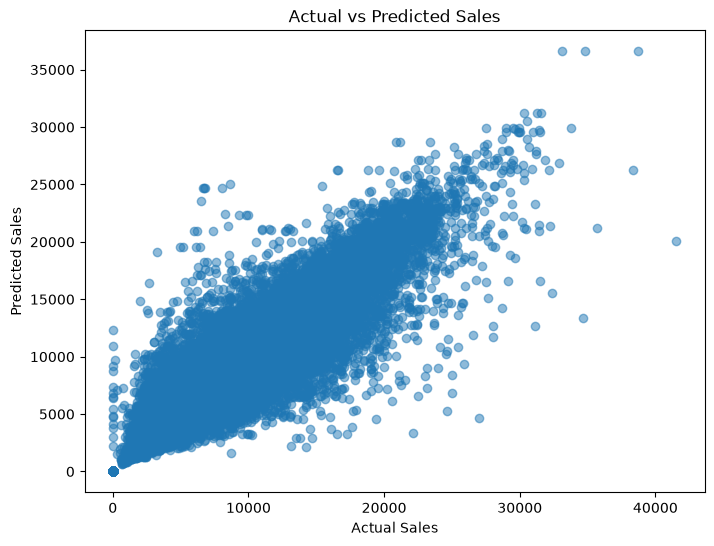

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [ ]:
dt_saving_path = r"..\backend\models\dt_model.pkl"
joblib.dump(grid.best_estimator_, dt_saving_path)

['..\\models\\dt_model.pkl']

## Random Forest Regressor

In [15]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [35, 40, 45],
    'min_samples_split': [8, 10, 12],
    'min_samples_leaf': [2, 3, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    verbose=1
)

In [16]:
with mlflow.start_run(run_name="RandomForest"):
    random_search.fit(X_train, y_train)
    y_pred = random_search.predict(X_test)
    train_pred = random_search.predict(X_train)

    best_parameter = random_search.best_params_
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2_test = r2_score(y_test, y_pred)
    r2_train = r2_score(y_train, train_pred)

    mlflow.log_params(best_parameter)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2_test", r2_test)
    mlflow.log_metric("r2_train", r2_train)

    mlflow.sklearn.log_model(random_search.best_estimator_, "RandomForest_model")

    print(f"Best params: {best_parameter}")
    print(f"RMSE: {rmse:.4f} | R2 Test: {r2_test:.4f} | R2 Train: {r2_train:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits


2026/06/13 11:36:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 11:36:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best params: {'n_estimators': 100, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 35}
RMSE: 1283.1165 | R2 Test: 0.8888 | R2 Train: 0.9345


In [17]:
best_model = random_search.best_estimator_
importance = best_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})
feature_importance

,Feature,Importance
0,StateHoliday,0.036067
1,PromoInterval,0.012842
2,StoreType,0.024764
3,Assortment,0.017730
4,DayOfWeek,0.184836
5,Open,0.275900
6,Promo,0.123567
7,SchoolHoliday,0.005116
8,CompetitionDistance,0.175112
9,Promo2,0.004928


In [18]:
print("MSE  :", mse)
print("MAE :", mae)
print("RMSE :", rmse)
print("R2 Test :", r2_test)
print("R2 Train:", r2_train)

MSE  : 1646387.8950708823
MAE : 794.9577405161564
RMSE : 1283.1164775930836
R2 Test : 0.8887669808523755
R2 Train: 0.9344621052799913


In [19]:
logger.info("[RandomForest] Train R2: %.4f | Test R2: %.4f", r2_train, r2_test)

2026-06-13 11:37:09 | INFO     | modeling | [RandomForest] Train R2: 0.9345 | Test R2: 0.8888


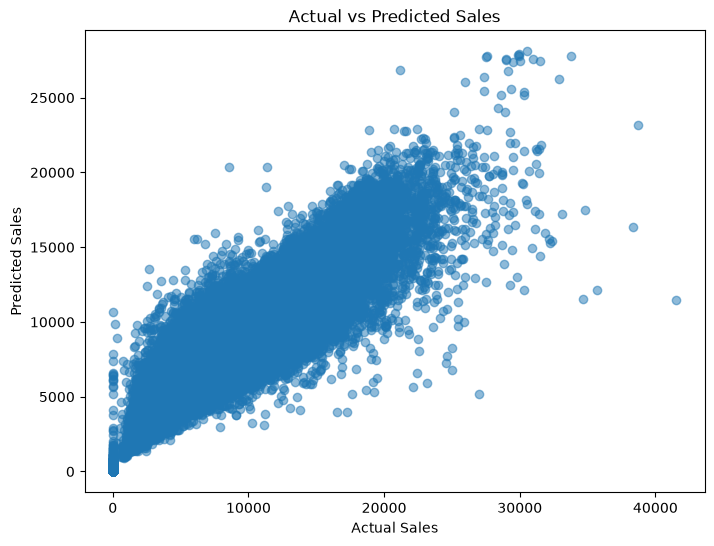

In [20]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [ ]:
rf_saving_path = r"..\backend\models\rf_model.pkl"
joblib.dump(random_search.best_estimator_, rf_saving_path)

['..\\models\\rf_model.pkl']

## XGBoost Regressor

In [22]:
from xgboost import XGBRegressor

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb = XGBRegressor(
    random_state=42,
    tree_method='hist',
    verbosity=0
)

xgb_search = RandomizedSearchCV(
    xgb,
    param_distributions=xgb_param_grid,
    n_iter=20,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    verbose=1
)

In [23]:
with mlflow.start_run(run_name="XGBoost"):
    xgb_search.fit(X_train, y_train)
    y_pred = xgb_search.predict(X_test)
    train_pred = xgb_search.predict(X_train)

    best_parameter = xgb_search.best_params_
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2_test = r2_score(y_test, y_pred)
    r2_train = r2_score(y_train, train_pred)

    mlflow.log_params(best_parameter)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2_test", r2_test)
    mlflow.log_metric("r2_train", r2_train)

    mlflow.sklearn.log_model(xgb_search.best_estimator_, "xgboost_model")

    print(f"Best params: {best_parameter}")
    print(f"RMSE: {rmse:.4f} | R2 Test: {r2_test:.4f} | R2 Train: {r2_train:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits


2026/06/13 11:43:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 11:43:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best params: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
RMSE: 1109.9494 | R2 Test: 0.9168 | R2 Train: 0.9209


In [24]:
best_xgb = xgb_search.best_estimator_
importance = best_xgb.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})
feature_importance.sort_values("Importance", ascending=False)

,Feature,Importance
5,Open,0.571595
6,Promo,0.107225
3,Assortment,0.058366
8,CompetitionDistance,0.056653
2,StoreType,0.050049
1,PromoInterval,0.044104
11,CompetitionOpenSinceDays,0.023259
4,DayOfWeek,0.021654
13,Month,0.018487
7,SchoolHoliday,0.018236


In [25]:
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAE :", mae)
print("R2 Test :", r2_test)
print("R2 Train:", r2_train)

MSE  : 1231987.75
RMSE : 1109.9494357852523
MAE : 729.58447265625
R2 Test : 0.9167646169662476
R2 Train: 0.9209298491477966


In [26]:
logger.info("[XGBoost] Train R2: %.4f | Test R2: %.4f", r2_train, r2_test)

2026-06-13 11:43:30 | INFO     | modeling | [XGBoost] Train R2: 0.9209 | Test R2: 0.9168


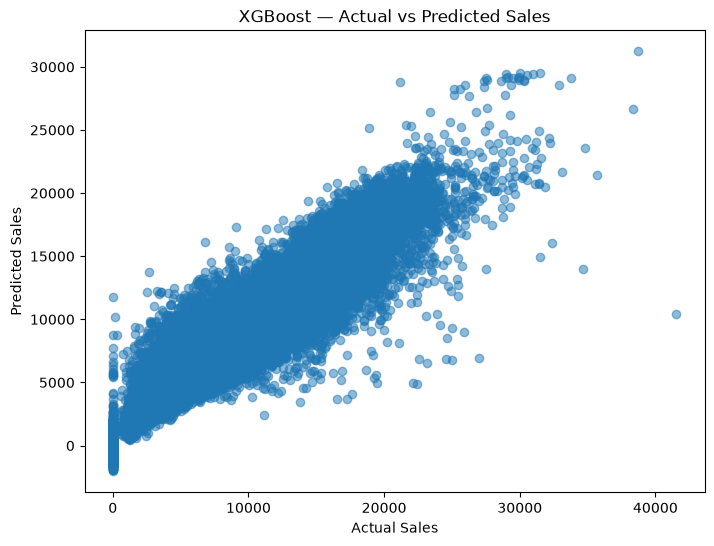

In [27]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("XGBoost — Actual vs Predicted Sales")

plt.show()

In [ ]:
xg_saving_path = r"..\backend\models\xgboost_model.pkl"
joblib.dump(xgb_search.best_estimator_, xg_saving_path)

['..\\models\\xgboost_model.pkl']